In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("/home/sae-itoshi/projects/prosperity-4/data_capsule/ROUND_2/trades_round_2_day_0.csv", sep=";")
prices = pd.read_csv("/home/sae-itoshi/projects/prosperity-4/data_capsule/ROUND_2/prices_round_2_day_0.csv", sep=";")

# filter
osmium = df[df["symbol"] == "ASH_COATED_OSMIUM"].copy()
prices = prices[prices["product"] == "ASH_COATED_OSMIUM"].copy()


# sort
osmium = osmium.sort_values("timestamp")
prices = prices.sort_values("timestamp")

# robust merge
osmium = pd.merge_asof(
    osmium,
    prices[["timestamp", "mid_price"]],
    on="timestamp",
    direction="backward"
)

# classify trades
osmium["buy_volume"] = np.where(osmium["price"] >= osmium["mid_price"], osmium["quantity"], 0)
osmium["sell_volume"] = np.where(osmium["price"] < osmium["mid_price"], osmium["quantity"], 0)

# set index
# osmium = osmium.set_index("timestamp")

# resample
# resampled = osmium.resample("200ms").agg({
#     "price": "last",
#     "quantity": "sum",
#     "buy_volume": "sum",
#     "sell_volume": "sum"
# })
bin_size = 5000   # try 1000–5000 depending on density
osmium["time_bin"] = (osmium["timestamp"] // bin_size) * bin_size; 

resampled = osmium.groupby("time_bin").agg({
    "price": "last",
    "quantity": "sum",
    "buy_volume": "sum",
    "sell_volume": "sum"
}).reset_index()
resampled["price"] = resampled["price"].ffill()
# fix NaNs properly
resampled["price"] = resampled["price"].ffill()
resampled["quantity"] = resampled["quantity"].fillna(0)
resampled["buy_volume"] = resampled["buy_volume"].fillna(0)
resampled["sell_volume"] = resampled["sell_volume"].fillna(0)


print(resampled.head())
print(resampled["quantity"].sum())
print(len(resampled))

   time_bin    price  quantity  buy_volume  sell_volume
0         0  10002.0        11           5            6
1      5000   9989.0        10           0           10
2     10000   9989.0        13           0           13
3     15000  10010.0        16          16            0
4     20000   9991.0        11           0           11
2348
179


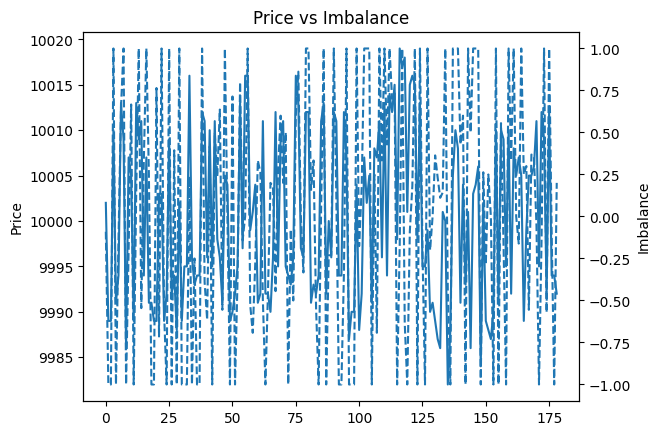

In [ ]:
# PLOT 1 ORDER FLOW IMBALANCE VS PRICE
df = resampled.copy()

df["imbalance"] = (
    df["buy_volume"] - df["sell_volume"]
) / (df["buy_volume"] + df["sell_volume"] + 1e-9)

df = df.dropna()

fig, ax1 = plt.subplots()

ax1.plot(df.index, df["price"])
ax1.set_ylabel("Price")

ax2 = ax1.twinx()
ax2.plot(df.index, df["imbalance"], linestyle="dashed")
ax2.set_ylabel("Imbalance")

plt.title("Price vs Imbalance")
plt.show()

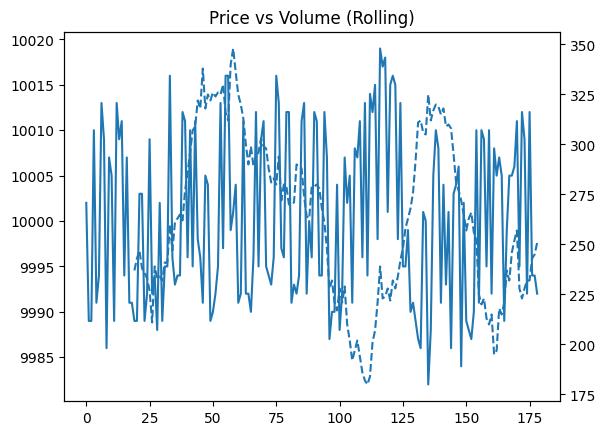

In [ ]:
#PLOT 2 VOLUME SPIKES VS PRICE
window = 20
df["vol_rolling"] = df["quantity"].rolling(window).sum()

fig, ax1 = plt.subplots()

ax1.plot(df.index, df["price"])

ax2 = ax1.twinx()
ax2.plot(df.index, df["vol_rolling"], linestyle="dashed")

plt.title("Price vs Volume (Rolling)")
plt.show()

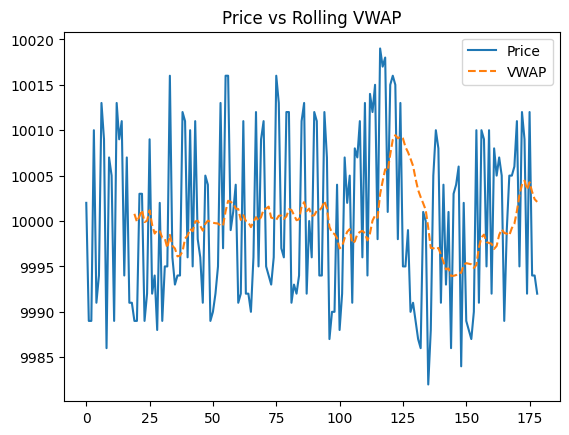

In [ ]:
# PLOT 3 VWAP VS PRICE
window = 20

df["vwap"] = (
    (df["price"] * df["quantity"]).rolling(window).sum() /
    (df["quantity"].rolling(window).sum() + 1e-9)
)

plt.figure()
plt.plot(df.index, df["price"], label="Price")
plt.plot(df.index, df["vwap"], linestyle="dashed", label="VWAP")

plt.legend()
plt.title("Price vs Rolling VWAP")
plt.show()

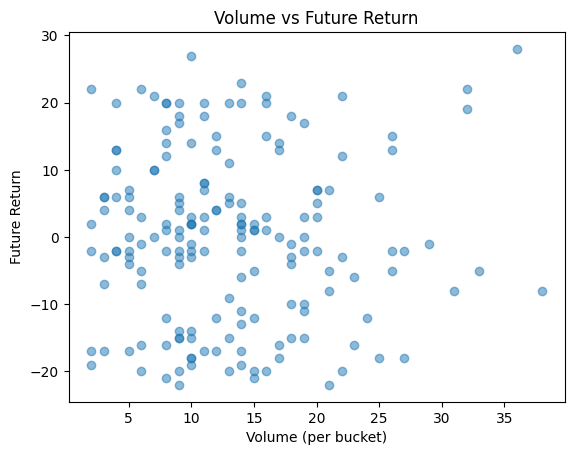

In [ ]:
# plot 4 Trade Size vs Price Impact
# future return over next k buckets
k = 3
df["future_return"] = df["price"].shift(-k) - df["price"]

plt.figure()
plt.scatter(df["quantity"], df["future_return"], alpha=0.5)

plt.xlabel("Volume (per bucket)")
plt.ylabel("Future Return")
plt.title("Volume vs Future Return")
plt.show()

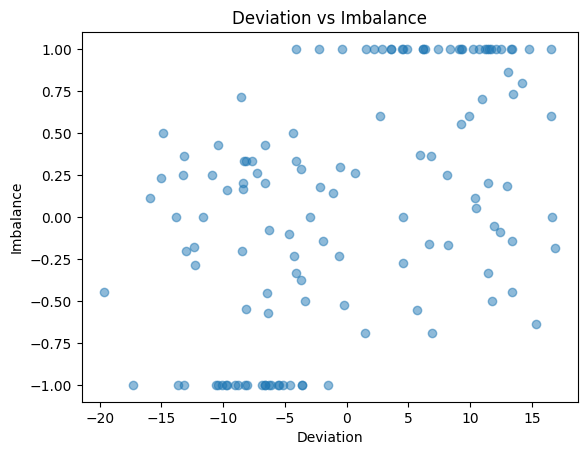

In [ ]:
# PLOT 5 DEVIATION FROM MA VS IMBALANCE
# moving average from trades (or use prices.csv MA)
window = 50

df["ma"] = df["price"].rolling(window).mean()
df["deviation"] = df["price"] - df["ma"]

plt.figure()
plt.scatter(df["deviation"], df["imbalance"], alpha=0.5)

plt.xlabel("Deviation")
plt.ylabel("Imbalance")
plt.title("Deviation vs Imbalance")
plt.show()

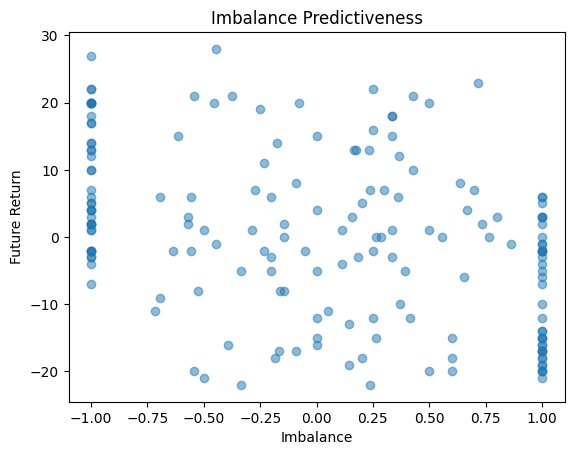

In [ ]:
k = 3
df["future_return"] = df["price"].shift(-k) - df["price"]

plt.figure()
plt.scatter(df["imbalance"], df["future_return"], alpha=0.5)

plt.xlabel("Imbalance")
plt.ylabel("Future Return")
plt.title("Imbalance Predictiveness")
plt.show()

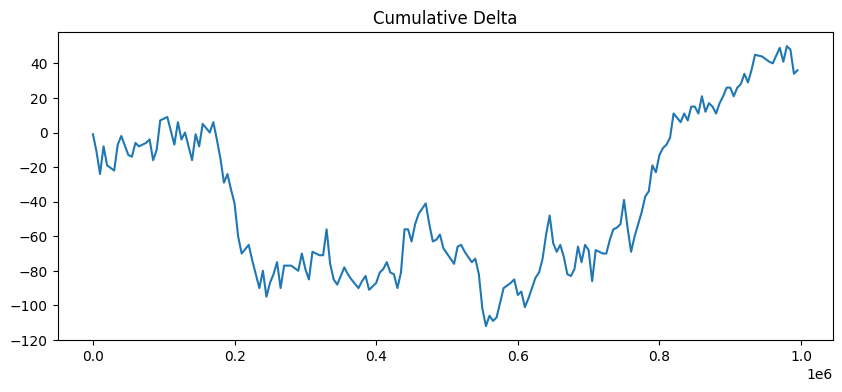

In [ ]:
resampled["delta"] = resampled["buy_volume"] - resampled["sell_volume"]
resampled["cum_delta"] = resampled["delta"].cumsum()

plt.figure(figsize=(10,4))
plt.plot(resampled["time_bin"], resampled["cum_delta"])
plt.title("Cumulative Delta")
plt.show()

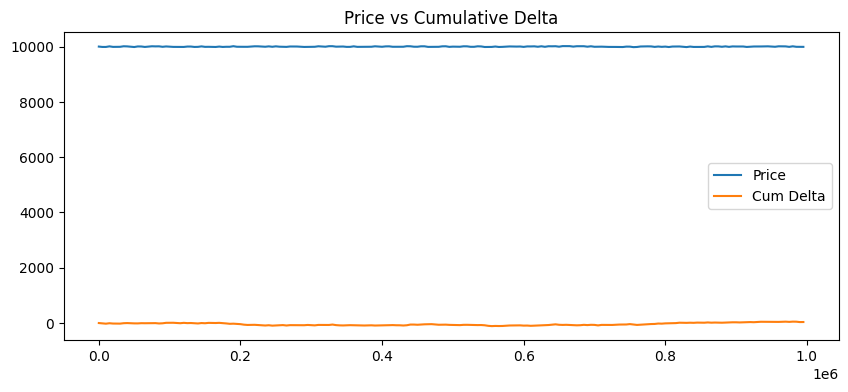

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(resampled["time_bin"], resampled["price"], label="Price")
plt.plot(resampled["time_bin"], resampled["cum_delta"], label="Cum Delta")
plt.legend()
plt.title("Price vs Cumulative Delta")
plt.show()

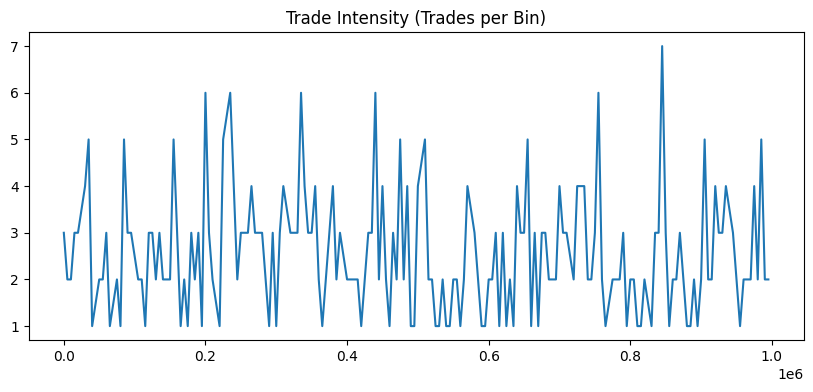

In [ ]:
resampled["trade_count"] = osmium.groupby("time_bin").size().values

plt.figure(figsize=(10,4))
plt.plot(resampled["time_bin"], resampled["trade_count"])
plt.title("Trade Intensity (Trades per Bin)")
plt.show()

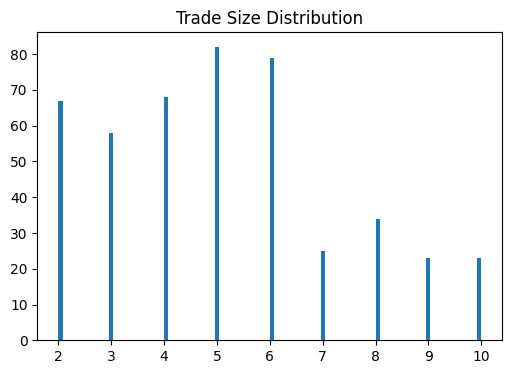

In [ ]:
plt.figure(figsize=(6,4))
plt.hist(osmium["quantity"], bins=100)
plt.title("Trade Size Distribution")
plt.show()

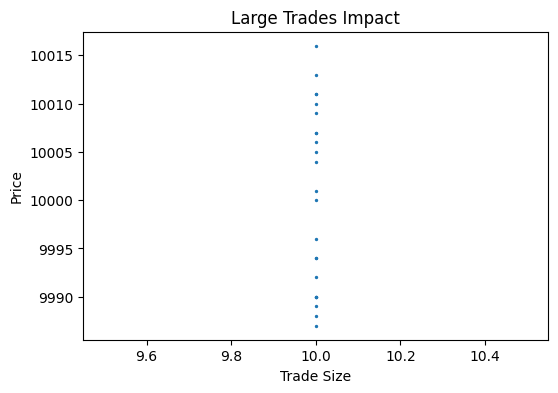

In [ ]:
threshold = osmium["quantity"].quantile(0.95)
large_trades = osmium[osmium["quantity"] > threshold]

plt.figure(figsize=(6,4))
plt.scatter(large_trades["quantity"], large_trades["price"], s=2)
plt.xlabel("Trade Size")
plt.ylabel("Price")
plt.title("Large Trades Impact")
plt.show()

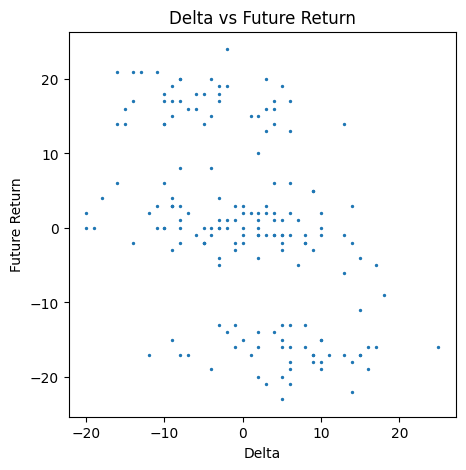

In [ ]:
resampled["future_return"] = resampled["price"].shift(-1) - resampled["price"]

plt.figure(figsize=(5,5))
plt.scatter(resampled["delta"], resampled["future_return"], s=2)
plt.xlabel("Delta")
plt.ylabel("Future Return")
plt.title("Delta vs Future Return")
plt.show()

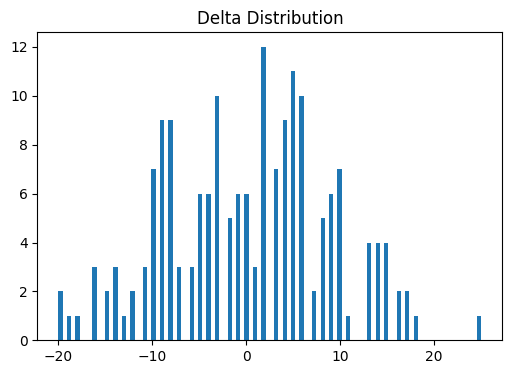

In [ ]:
plt.figure(figsize=(6,4))
plt.hist(resampled["delta"], bins=100)
plt.title("Delta Distribution")
plt.show()

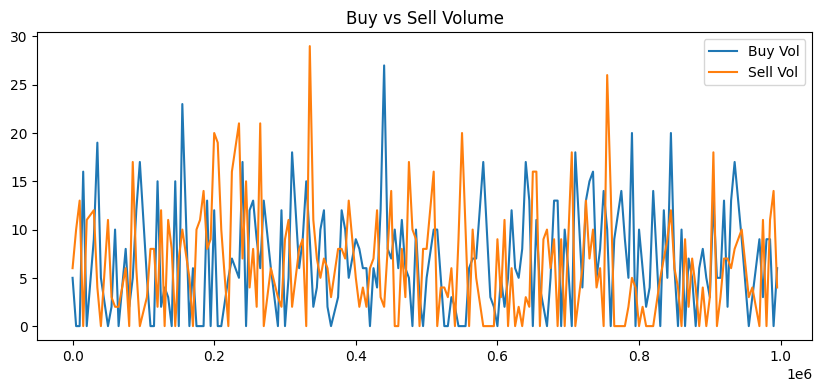

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(resampled["time_bin"], resampled["buy_volume"], label="Buy Vol")
plt.plot(resampled["time_bin"], resampled["sell_volume"], label="Sell Vol")
plt.legend()
plt.title("Buy vs Sell Volume")
plt.show()

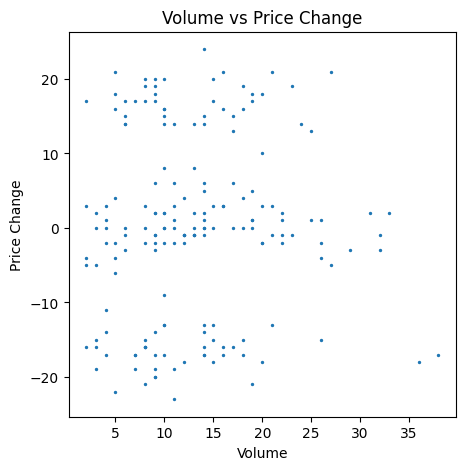

In [ ]:
resampled["volume"] = resampled["quantity"]
resampled["price_change"] = resampled["price"].diff()

plt.figure(figsize=(5,5))
plt.scatter(resampled["volume"], resampled["price_change"], s=2)
plt.xlabel("Volume")
plt.ylabel("Price Change")
plt.title("Volume vs Price Change")
plt.show()

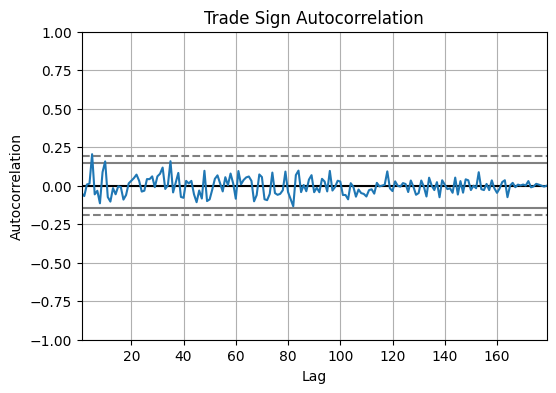

In [ ]:
resampled["sign"] = np.sign(resampled["delta"])

from pandas.plotting import autocorrelation_plot

plt.figure(figsize=(6,4))
autocorrelation_plot(resampled["sign"].dropna())
plt.title("Trade Sign Autocorrelation")
plt.show()

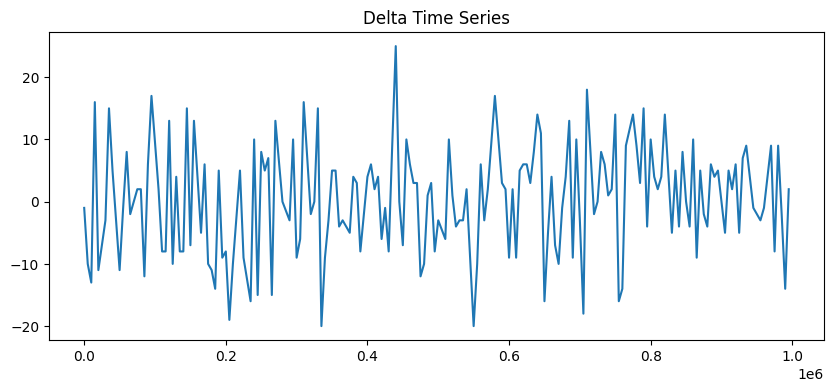

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(resampled["time_bin"], resampled["delta"])
plt.title("Delta Time Series")
plt.show()

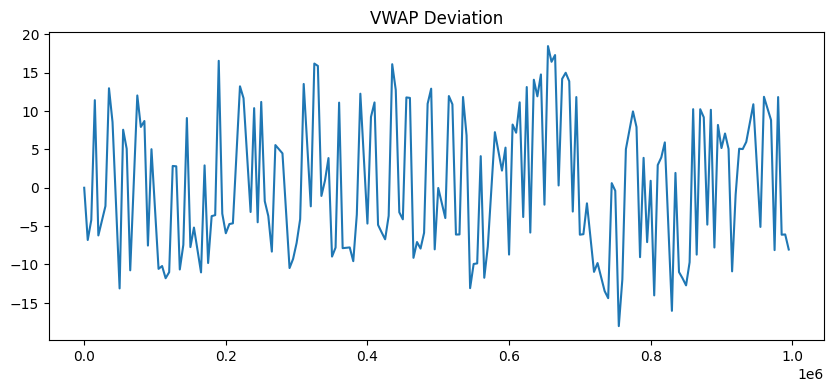

In [ ]:
resampled["vwap"] = (resampled["price"] * resampled["quantity"]).cumsum() / resampled["quantity"].cumsum()
resampled["vwap_dev"] = resampled["price"] - resampled["vwap"]

plt.figure(figsize=(10,4))
plt.plot(resampled["time_bin"], resampled["vwap_dev"])
plt.title("VWAP Deviation")
plt.show()

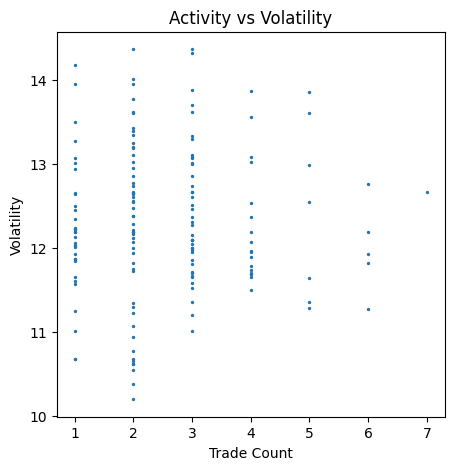

In [ ]:
resampled["volatility"] = resampled["price"].diff().rolling(20).std()

plt.figure(figsize=(5,5))
plt.scatter(resampled["trade_count"], resampled["volatility"], s=2)
plt.xlabel("Trade Count")
plt.ylabel("Volatility")
plt.title("Activity vs Volatility")
plt.show()

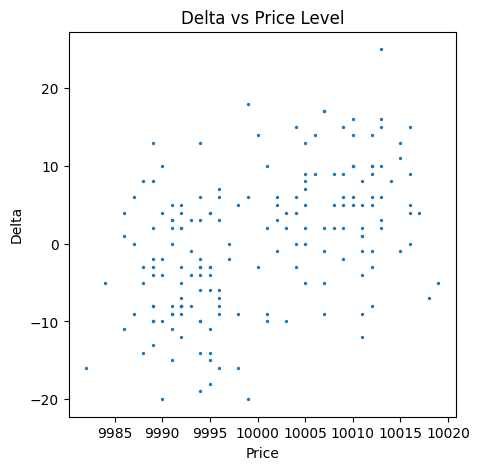

In [ ]:
plt.figure(figsize=(5,5))
plt.scatter(resampled["price"], resampled["delta"], s=2)
plt.xlabel("Price")
plt.ylabel("Delta")
plt.title("Delta vs Price Level")
plt.show()

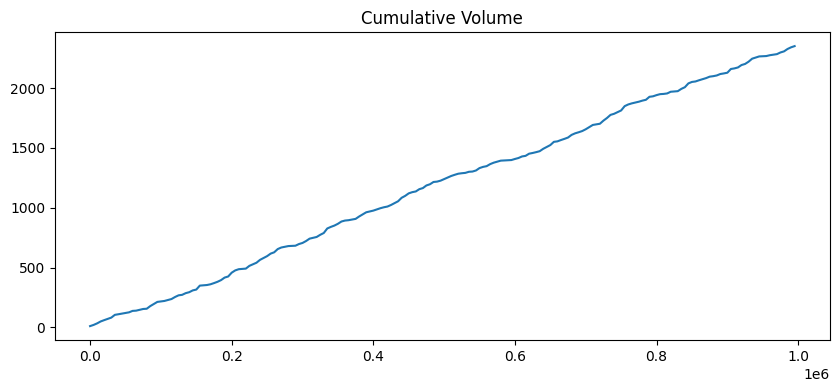

In [ ]:
resampled["cum_volume"] = resampled["quantity"].cumsum()

plt.figure(figsize=(10,4))
plt.plot(resampled["time_bin"], resampled["cum_volume"])
plt.title("Cumulative Volume")
plt.show()